# Project Ex. 3

## Reminder: US Accidents (New York Subset) Dataset Overview

[Our dataset](https://docs.google.com/spreadsheets/d/1KY1tcftko3W9Fp-ZbceReVZD2G58tGEhJw6xMqyzIDw/edit?usp=sharing) (generated in ProjEx1) is a processed subset of the nationwide US Accidents (2016–2023) [dataset](https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents), filtered for incidents occurring in NYC ($N=18,883$ after cleaning).

| Var | Type | Data Type | Description |
| --- | --- | --- | --- |
| **`accident_id`** | Categorical | `int64` | Unique numeric identifier extracted from the original ID. |
| **`severity_of_traffic`** | Ordinal | `int8` | Severity score **1–4** (1 = lowest impact, 4 = highest impact). |
| **`traffic_disruption_duration`** | Continuous | `float64` | Duration of the traffic impact in **hours**. |
| **`distance_of_traffic`** | Continuous | `float64` | Distance in **miles** over which traffic flow was affected. |
| **`is_day`** | Binary | `int8` | **1** = Day, **0** = Night (derived from Sunrise/Sunset). |
| **`is_traffic_signal`** | Binary | `int8` | **1** = Yes, **0** = No (presence of a traffic signal nearby). |

The dataset focuses on traffic impact, where both duration and distance exhibit extreme right-skewness. `traffic_disruption_duration` contains massive outliers (up to ~3,967h) despite a low median (1.26h), while `distance_of_traffic` is also zero-inflated.

## Importing the data

In [2]:
import pandas as pd

url = "https://docs.google.com/spreadsheets/d/1mJ3MtFkxHFdTEki1HjrdkAfIvekmWvltFn5S1KRnna8/export?format=csv"
df = pd.read_csv(url)
df.head()

,accident_id,severity_of_traffic,traffic_disruption_duration,distance_of_traffic,is_day,is_traffic_signal
0,194408,2,0.493611,0.01,1,1
1,194422,3,0.494167,1.13,1,0
2,194475,2,0.491389,0.01,1,0
3,194540,2,0.497500,0.01,0,1
4,194558,2,0.492222,0.01,1,1


In [3]:
df.drop(columns=['accident_id', 'is_day', 'is_traffic_signal']).describe()

,severity_of_traffic,traffic_disruption_duration,distance_of_traffic
count,18883.000000,18883.000000,18883.000000
mean,2.223270,3.770666,0.520394
std,0.472117,64.703107,0.794297
min,1.000000,0.091667,0.000000
25%,2.000000,0.500000,0.000000
50%,2.000000,1.260556,0.137000
75%,2.000000,2.375000,0.782000
max,4.000000,3943.225278,8.502000


## Part A: Linear Regression 


### Section (a): Research question
We have chosen the following: 
- Response Variable: `traffic_disruption_duration` (continuous)
- Explanatory Variables: `is_traffic_signal` (binary), `distance_of_traffic` (continuous), `severity_of_traffic` (ordinal)

Respictivly, our research question is:

*How does the presence of a nearby traffic signal, distance of traffic disruption, and severity of traffic impact influence the duration of traffic disruption caused by accidents in NYC?*

### Section (b): Subsampling
Subsampling to 1000 and 200 observations for analysis.

In [4]:
df_partA = df.sample(n=1200, random_state=42)
df_200 = df_partA[:200]
df_1000 = df_partA[200:]

print("Sizes of 200 and 1000 samples:", df_200.shape, df_1000.shape)

Sizes of 200 and 1000 samples: (200, 6) (1000, 6)


### Section (c): Exploratory Data Analysis
#### Sub-Section (1) Histograms and tables

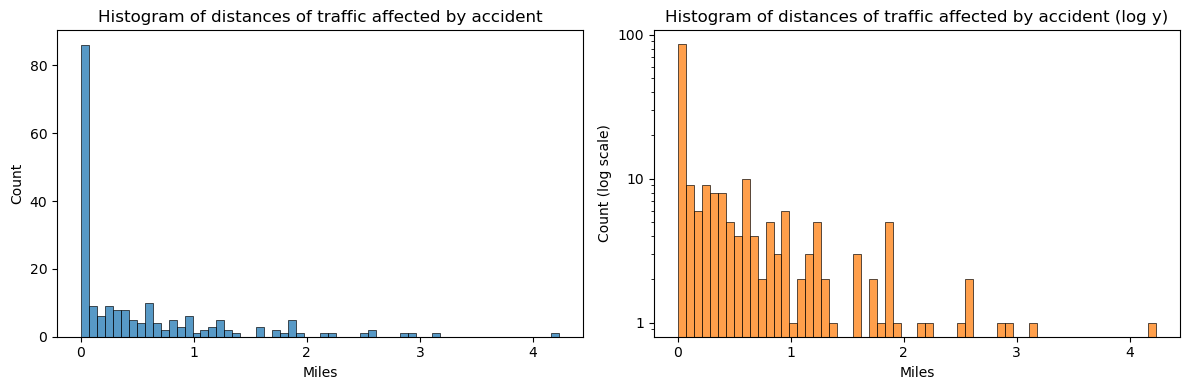

distance_of_traffic mean: 0.5058 variance: 0.5235
Frequency: is_traffic_signal (0=No, 1=Yes)


,count,percent
is_traffic_signal,,
0,153,76.5
1,47,23.5


Frequency: severity_of_traffic (ordinal 1-4)


,count,percent
severity_of_traffic,,
2,161,80.5
3,34,17.0
4,5,2.5


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Histograms of distances of traffic affected by accident: left linear y, right log y (full data)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_200["distance_of_traffic"], bins=60, color="#1f77b4", ax=axes[0])
axes[0].set_title("Histogram of distances of traffic affected by accident")
axes[0].set_xlabel("Miles")
axes[0].set_ylabel("Count")

sns.histplot(df_200["distance_of_traffic"], bins=60, color="#ff7f0e", ax=axes[1])
axes[1].set_title("Histogram of distances of traffic affected by accident (log y)")
axes[1].set_xlabel("Miles")
axes[1].set_ylabel("Count (log scale)")
axes[1].set_yscale("log")
axes[1].yaxis.set_major_formatter(mtick.ScalarFormatter())
axes[1].yaxis.set_minor_formatter(mtick.NullFormatter())
axes[1].ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

# Summary statistics for distance_of_traffic
dist_mean = df_200["distance_of_traffic"].mean()
dist_var = df_200["distance_of_traffic"].var()
print(f"distance_of_traffic mean: {dist_mean:.4f} variance: {dist_var:.4f}")

# Tables for binary/ordinal variables
def freq_table(series, name):
    vc = series.value_counts(dropna=False)
    pct = series.value_counts(normalize=True, dropna=False) * 100
    out = pd.DataFrame({"count": vc, "percent": pct.round(2)})
    out.index.name = name
    return out

print("Frequency: is_traffic_signal (0=No, 1=Yes)")
display(freq_table(df_200["is_traffic_signal"], "is_traffic_signal"))

print("Frequency: severity_of_traffic (ordinal 1-4)")
display(freq_table(df_200["severity_of_traffic"], "severity_of_traffic"))

#### Sub-Section (2) Data and Dist. Analysis

For the ordinal (`severity_of_traffic`) and binary (`is_traffic_signal`) explanatory variables, we can see that after sampling the `severity=1` categoery is missing, and `severity=4` is only $2.5\%$. Other then that we see no missing data. None of the variables are symmetric (They are all positive). We could use a naive bernouli or multinom models to estimate the probabilities of both variables. Most accidents appear with a traffic signal ($76.5\%$) and are of `severity=2` ($80\%$)

 The dist. of `distance_of_traffic` shows somewhat abnormal zero inflation and a right tail with many outliers. This leads us to hypothesize that `distance_of_traffic` is taken fron an **exponential** dist. We will inspect this using a QQ-Plot.

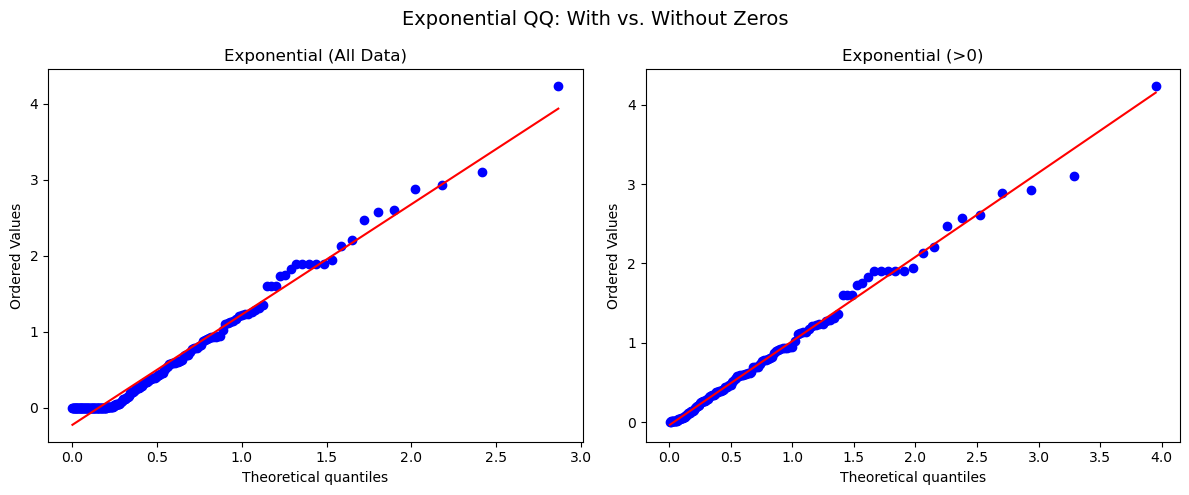

In [6]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. Prepare Data Subsets
data_all = df_200['distance_of_traffic']
# Filter for non-zeros for the second set of plots
data_nonzero = data_all[data_all > 0]

# --- Side-by-side QQ plots: WITH and WITHOUT zeros ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Exponential QQ: With vs. Without Zeros', fontsize=14)

# With zeros
params_exp = stats.expon.fit(data_all, floc=0)
stats.probplot(data_all, dist="expon", sparams=params_exp, plot=axes[0])
axes[0].set_title("Exponential (All Data)")
axes[0].set_xlabel("Theoretical quantiles")
axes[0].set_ylabel("Ordered Values")

# Without zeros (>0)
params_exp_nz = stats.expon.fit(data_nonzero, floc=0)
stats.probplot(data_nonzero, dist="expon", sparams=params_exp_nz, plot=axes[1])
axes[1].set_title("Exponential (>0)")
axes[1].set_xlabel("Theoretical quantiles")
axes[1].set_ylabel("Ordered Values")

plt.tight_layout()
plt.show()

Fitting standard distributions (Log-Normal, Gamma) to the full dataset failed because they cannot model at $X=0$. We isolated the positive values ($X > 0$), and Q-Q plots suggested that the Exponential distribution fits the non-zero data better (see the vertical line near zero on the left plot). We propose a mix model: Bernoulli trial to model traffic occurrence ($X>0$) and an Exponential distribution to model the distance. 
$$f(x) =
\begin{cases}
    \hat{p} & \text{if } x = 0 \\
    (1 - \hat{p}) \cdot \hat{\lambda} e^{-\hat{\lambda} x} & \text{if } x > 0
\end{cases}$$

We empirically estimated the paramters using MLE:

In [7]:
# Assuming df['distance_of_traffic'] is your data
data = df_200['distance_of_traffic']

# 1. Calculate the Binary Component (Bernoulli)
n_total = len(data)
n_zeros = (data == 0).sum()
p_zero = n_zeros / n_total

# 2. Calculate the Continuous Component (Manual MLE)
# Filter for non-zero values
data_nonzero = data[data > 0]

# MLE for Exponential Distribution: lambda = 1 / mean
mean_nonzero = data_nonzero.mean()
lambda_param = 1 / mean_nonzero

print(f"--- Hurdle Model Parameters (MLE) ---")
print(f"Probability of Zero (p): {p_zero:.4f}")
print(f"Mean of non-zeros:       {mean_nonzero:.4f}")
print(f"Exponential Rate (λ):    {lambda_param:.4f}")

--- Hurdle Model Parameters (MLE) ---
Probability of Zero (p): 0.3250
Mean of non-zeros:       0.7493
Exponential Rate (λ):    1.3345


#### Sub-Section (3): Continous explanatory variables

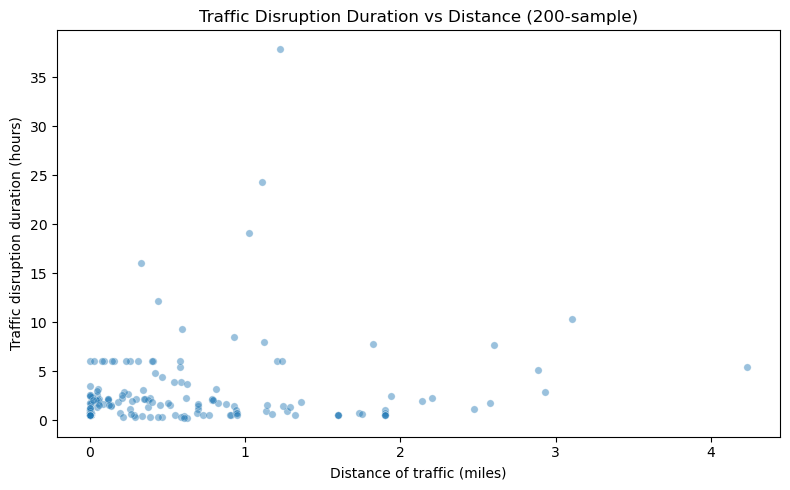

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter: distance_of_traffic (X) vs traffic_disruption_duration (Y)
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=df_200,
    x="distance_of_traffic",
    y="traffic_disruption_duration",
    alpha=0.45,
    s=28,
    ax=ax,
    color="#1f77b4"
)

ax.set_title("Traffic Disruption Duration vs Distance (200-sample)")
ax.set_xlabel("Distance of traffic (miles)")
ax.set_ylabel("Traffic disruption duration (hours)")

plt.tight_layout()
plt.show()

This is the only continuous explanatory variable. There is no clear correlation between traffic distance ($X$) and disruption duration ($Y$). The data is clustered in the short-distance range ($0$ to $1.5$ miles), yet within this specific cluster, the duration varies. This high variance, combined with the visible horizontal banding (suggesting discrete or rounded time values), overshadows a slight positive trend visible in the graph. This means longer distances don't always correlate with longer delays.

#### Sub-Section (4): Discrete explanatory variables

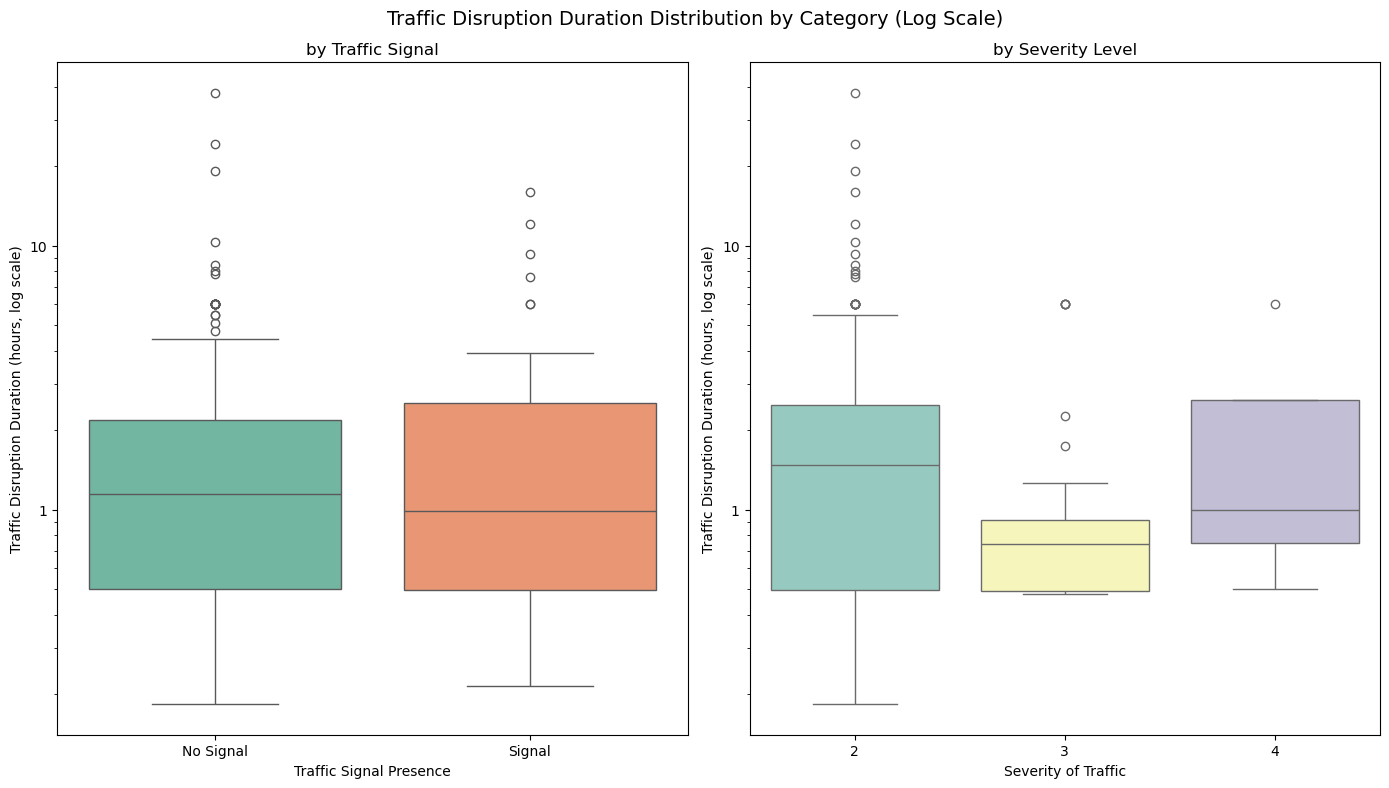

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Create figure for boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.suptitle('Traffic Disruption Duration Distribution by Category (Log Scale)', fontsize=14)

# Boxplot for is_traffic_signal
df_200_signal = df_200.copy()
df_200_signal['is_traffic_signal_label'] = df_200_signal['is_traffic_signal'].map({0: 'No Signal', 1: 'Signal'})
sns.boxplot(
    data=df_200_signal,
    x='is_traffic_signal_label',
    y='traffic_disruption_duration',
    hue='is_traffic_signal_label',
    ax=axes[0],
    palette='Set2',
    legend=False
)
axes[0].set_xlabel('Traffic Signal Presence')
axes[0].set_ylabel('Traffic Disruption Duration (hours, log scale)')
axes[0].set_title('by Traffic Signal')

# Boxplot for severity_of_traffic
sns.boxplot(
    data=df_200,
    x='severity_of_traffic',
    y='traffic_disruption_duration',
    hue='severity_of_traffic',
    ax=axes[1],
    palette='Set3',
    legend=False
)
axes[1].set_xlabel('Severity of Traffic')
axes[1].set_ylabel('Traffic Disruption Duration (hours, log scale)')
axes[1].set_title('by Severity Level')

# Apply log scale with custom formatter
axes[0].set_yscale('log')
axes[1].set_yscale('log')

# Custom formatter to display 1, 10, 100 instead of 10^0, 10^1, 10^2
log_formatter = FuncFormatter(lambda x, pos: f'{int(x)}')
axes[0].yaxis.set_major_formatter(log_formatter)
axes[1].yaxis.set_major_formatter(log_formatter)

plt.tight_layout()
plt.show()

The figure illustrates the distribution of traffic disruption durations (log-scale) categorized by signal presence and severity level. Visually, the presence of a traffic signal shows no impact on median duration, though the "No Signal" group exhibits a higher frequency of extreme outliers. Regarding severity, severity Level 3 displays a counter-intuitive drop in median duration compared to Level 2. This could be a result of the small sample size. We have elected not to display histograms since they provided to futher information.

### Section (d): Linear regression

In [10]:
import pandas as pd
import statsmodels.api as sm

# Linear Regression (OLS) on 200-sample with one-hot encoded severity
# Response: traffic_disruption_duration
# Predictors: is_traffic_signal (binary), distance_of_traffic (continuous), severity dummies (no linearity assumption)

# Base predictors
X_base = df_200[["is_traffic_signal", "distance_of_traffic"]].copy()

# One-hot encode severity; drop_first=True sets a reference category
severity_cat = df_200["severity_of_traffic"].astype("category")
severity_dummies = pd.get_dummies(severity_cat, prefix="severity", drop_first=True)

# Build design matrix
X = pd.concat([X_base, severity_dummies], axis=1)
y = df_200["traffic_disruption_duration"].copy()

# Ensure numeric types
X = X.astype(float)
y = pd.to_numeric(y, errors="coerce")

# Add intercept
X = sm.add_constant(X, has_constant="add")

# Fit OLS
ols_model = sm.OLS(y, X, missing="drop").fit()

# Outputs
print("β̂ (coefficients):")
print(ols_model.params)

β̂ (coefficients):
const                  1.975202
is_traffic_signal      0.012334
distance_of_traffic    1.228853
severity_3            -1.342486
severity_4            -0.013436
dtype: float64


Our model is: 

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \beta_4 X_4$$

Where:

$X_1$ is the binary variable `is_traffic_signal` (1 if a traffic signal is present, 0 otherwise).

$X_2$ is the continuous variable `distance_of_traffic`.

$X_3$ and $X_4$ are one-hot encoding variables representing the ordinal variable `severity_of_traffic`. Specifically, $X_3$ corresponds to severity level 3 (1 if severity is 3, 0 otherwise), and $X_4$ corresponds to severity level 4 (1 if severity is 4, 0 otherwise). If severity=2, then both $X_3$ and $X_4$ are 0, if we haven't dropped it, then we could infer the value of the dropped variable from the other two, leading to multicollinearity.

We add a constant term to the design matrix to account for the intercept in the linear regression model. And we find:

$$\hat{\beta} = (1.975, 0.012,  1.229, -1.342, -0.013)$$

The model estimates a baseline disruption duration of 1.975 hours (Intercept) for incidents with no signal, zero distance, and Severity Level 2. For the continuous variable, `distance_of_traffic`, a one-unit increase corresponds to a 1.23-hour rise in duration. For binary and one-hot encoded variables (`is_traffic_signal` and Severity Levels), a "one-unit increase" has no physical meaning. These coefficients represent the fixed effect of switching categories relative to the baseline: the presence of a traffic signal adds a negligible 0.01 hours compared to no signal. Shifting to Severity Level 3 is associated with a 1.34-hour decrease, while shifting to Severity Level 4 results in a negligible 0.01-hour decrease, indicating that higher severity does not consistently predict longer durations in this sample.

### Section (e): Anova, F-test, $R^2$, $𝑅^2_\text{adj}$

In [11]:
from scipy.stats import f as f_dist

n = len(y)
k = X.shape[1] - 1
y_pred = ols_model.predict()

y_mean = y.mean()
SST = ((y - y_mean) ** 2).sum()
SSR = ((y_pred - y_mean) ** 2).sum()
SSE = ((y - y_pred) ** 2).sum()

df_reg, df_res = k, n - k - 1
MSR, MSE = SSR / df_reg, SSE / df_res
F_stat = MSR / MSE
p_value = 1 - f_dist.cdf(F_stat, df_reg, df_res)

R_sq = SSR / SST
Adj_R_sq = 1 - (SSE / df_res) / (SST / (n - 1))

# ANOVA Table
import pandas as pd
anova = pd.DataFrame({
    "Source": ["Regression", "Residual", "Total"],
    "SS": [SSR, SSE, SST],
    "df": [df_reg, df_res, n - 1],
    "MS": [MSR, MSE, np.nan],
    "F": [F_stat, np.nan, np.nan]
})

print("ANOVA TABLE")
print(anova.to_string(index=False))
print(f"\nF-TEST: F = {F_stat:.4f}, p-value = {p_value:.4f}")
print(f"R2 = {R_sq:.4f}, Adj. R2 = {Adj_R_sq:.4f}")
print(f"Conclusion: {'REJECT H0 (model significant)' if p_value < 0.05 else 'FAIL TO REJECT H0'}")

ANOVA TABLE
    Source          SS  df        MS        F
Regression  198.420338   4 49.605085 3.312626
  Residual 2920.037593 195 14.974552      NaN
     Total 3118.457931 199       NaN      NaN

F-TEST: F = 3.3126, p-value = 0.0119
R2 = 0.0636, Adj. R2 = 0.0444
Conclusion: REJECT H0 (model significant)


While we reject the null hypothesis that all coefficients are zero (p-value < 0.05), the model explains only a small fraction ($6\%$) of the variance in traffic disruption duration, with an $R^2$ of 0.06 and an adjusted $R^2$ of 0.0444, suggesting that other factors not included in the model may play a more substantial role.

### Section (f): CI for sample coeff. and coeff. for the whole population

Using: $\hat{\beta}_{i,n} \approx \mathcal{N}(\beta^0_i, {\sigma_\varepsilon^2(X^TX)^{-1}}_{i,i})$

Thus, a CI will be


$\hat{\beta_i} \pm z_{1-\frac{\alpha}{2}}\hat{se}(\hat{\beta_i})=\hat{\beta_i} \pm z_{1-\frac{\alpha}{2}} \sqrt{{MS_{\text{Res}}(X^TX)^{-1}}_{i,i}} $

                        lower     upper  beta_hat_full  full_beta_in_CI
const                1.155312  2.795092       3.654580            False
is_traffic_signal   -1.318146  1.342814       0.373056             True
distance_of_traffic  0.469202  1.988505       0.546260             True
severity_3          -2.816619  0.131647      -2.741697             True
severity_4          -3.511582  3.484711       9.580310            False


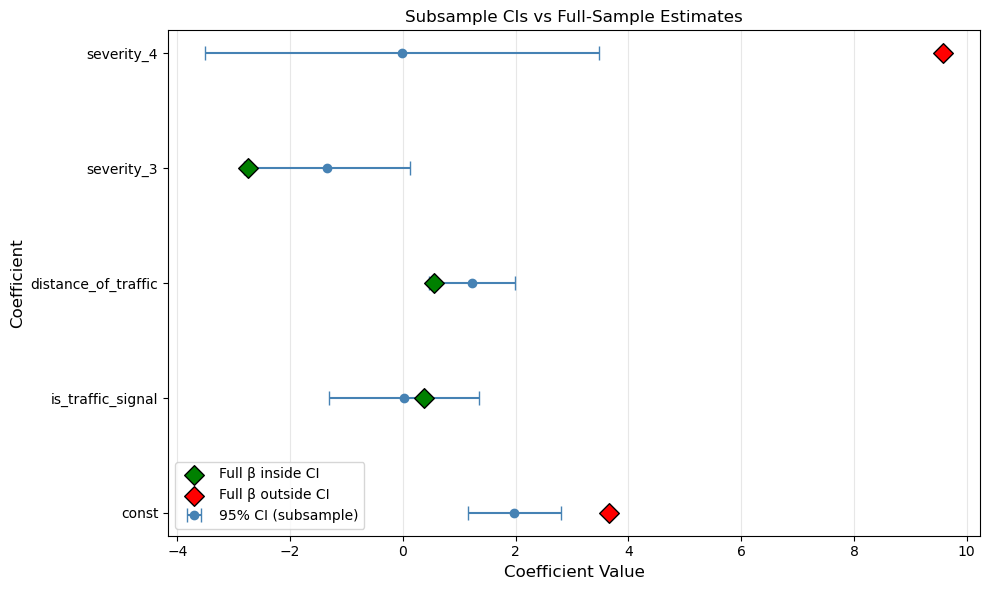

Subsample Sev 2 Mean: 2.5906176673372667
Full Sample Sev 2 Mean: 4.015183266920725


In [12]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Get CIs from the existing subsample model
ci_sub = ols_model.conf_int(alpha=0.05)
ci_sub.columns = ["lower", "upper"]
ci_sub["beta_hat_subsample"] = ols_model.params

# Fit full-sample model
# Using categories=[2, 1, 3, 4] ensures '2' remains the baseline (dropped)
# so coefficients are directly comparable to the subsample model.
severity_cat_full = pd.Series(
    pd.Categorical(df["severity_of_traffic"], categories=[2, 1, 3, 4], ordered=False),
    index=df.index
)
severity_dummies_full = pd.get_dummies(severity_cat_full, prefix="severity", drop_first=True)

X_full_base = df[["is_traffic_signal", "distance_of_traffic"]].copy()
X_full = pd.concat([X_full_base, severity_dummies_full], axis=1).astype(float)
X_full = sm.add_constant(X_full, has_constant="add")

y_full = pd.to_numeric(df["traffic_disruption_duration"], errors="coerce")
ols_full = sm.OLS(y_full, X_full).fit()

# Match indices for comparison (ignores severity_1 since it's not in subsample)
ci_sub["beta_hat_full"] = ols_full.params.reindex(ci_sub.index)
ci_sub["full_beta_in_CI"] = (ci_sub["beta_hat_full"] >= ci_sub["lower"]) & \
                            (ci_sub["beta_hat_full"] <= ci_sub["upper"])

print(ci_sub[["lower", "upper", "beta_hat_full", "full_beta_in_CI"]].to_string())

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

coef_names = ci_sub.index
y_pos = np.arange(len(coef_names))

# Subsample Error Bars
ci_mid = (ci_sub["lower"] + ci_sub["upper"]) / 2
ci_err = ci_sub["upper"] - ci_mid
ax.errorbar(ci_mid, y_pos, xerr=ci_err, fmt='o', capsize=5, 
            label='95% CI (subsample)', color='steelblue')

# Full-sample Markers
beta_full_vals = ci_sub["beta_hat_full"]
inside_ci = ci_sub["full_beta_in_CI"]

# Split into Green (Inside) and Red (Outside)
mask_green = inside_ci.fillna(False).values
if mask_green.any():
    ax.scatter(beta_full_vals[mask_green], y_pos[mask_green], marker='D', s=100, 
               c='green', label='Full β inside CI', edgecolors='k', zorder=3)

mask_red = ~inside_ci.fillna(True).values
if mask_red.any():
    ax.scatter(beta_full_vals[mask_red], y_pos[mask_red], marker='D', s=100, 
               c='red', label='Full β outside CI', edgecolors='k', zorder=3)

ax.set_yticks(y_pos)
ax.set_yticklabels(coef_names)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_ylabel('Coefficient', fontsize=12)
ax.set_title('Subsample CIs vs Full-Sample Estimates')
ax.legend(loc='best')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Subsample Sev 2 Mean:", df_200[df_200['severity_of_traffic']==2]['traffic_disruption_duration'].mean())
print("Full Sample Sev 2 Mean:", df[df['severity_of_traffic']==2]['traffic_disruption_duration'].mean())

We validated the subsample model by estimating coefficients on the full dataset and checking if they fell within the subsample's 95% confidence intervals. We ensured Severity 2 remained the reference category, even when the full population has the `severity_1` category, so the intercepts would be directly comparable. While the coefficients for traffic signals and distance remained inside the intervals, the Intercept estimate fell significantly outside ($\hat{\beta} \approx 9.5$ vs $\approx 0$). Since the Intercept represents the average duration of Severity 2 traffic, this deviation confirms a sampling bias: the true average duration in the full population (4.02) is much higher than what our subsample captured (2.59).

### Section (g): Wald test to see if $\beta_i^* \neq 0$
$$H_0: \beta_i^* = 0$$
$$H_1: \beta_i^* \neq 0$$
$$T.S.: W = \frac{\beta_i^*}{\hat{se}}$$
$$\text{R.R.: } |W| \geq z_{1-\tilde{\frac \alpha2}}$$

In [13]:
import pandas as pd
import numpy as np
from scipy.stats import norm

# Wald test for all coefficients in the subsample model (df_200)
beta_hat = ols_model.params
se = ols_model.bse

# Calculate Wald statistics
wald_stat = beta_hat / se

# Calculate p-values (two-tailed test using standard normal)
p_values = 2 * (1 - norm.cdf(np.abs(wald_stat)))

# Critical value for α = 0.05 (two-tailed, standard normal)
alpha = 0.05
z_critical = norm.ppf(1 - alpha/2)
reject_H0 = np.abs(wald_stat) >= z_critical

# Create results table
wald_results = pd.DataFrame({
    'Coefficient': beta_hat,
    'Std Error': se,
    'Wald Stat (W)': wald_stat,
    'p-value': p_values,
    'Reject H₀': reject_H0
})

print("\n" + wald_results.to_string())
for coef_name in wald_results.index:
    decision = "REJECT H0" if wald_results.loc[coef_name, 'Reject H₀'] else "FAIL TO REJECT H₀"
    p_val = wald_results.loc[coef_name, 'p-value']
    print(f"  {coef_name}: {decision} (p = {p_val:.4f})")


                     Coefficient  Std Error  Wald Stat (W)   p-value  Reject H₀
const                   1.975202   0.415723       4.751248  0.000002       True
is_traffic_signal       0.012334   0.674616       0.018284  0.985413      False
distance_of_traffic     1.228853   0.385179       3.190343  0.001421       True
severity_3             -1.342486   0.747455      -1.796077  0.072482      False
severity_4             -0.013436   1.773724      -0.007575  0.993956      False
  const: REJECT H0 (p = 0.0000)
  is_traffic_signal: FAIL TO REJECT H₀ (p = 0.9854)
  distance_of_traffic: REJECT H0 (p = 0.0014)
  severity_3: FAIL TO REJECT H₀ (p = 0.0725)
  severity_4: FAIL TO REJECT H₀ (p = 0.9940)


We confirmed that `distance_of_traffic` is a reliable predictor and `is_traffic_signal` has no effect, as full-sample estimates for both fell within our subsample confidence intervals. However, the model failed to generalize for high-severity accidents: while the subsample deemed `severity_4` insignificant ($p \approx 0.99$), the full dataset reveals it drives a massive increase in disruption ($\beta \approx 9.5$). This discrepancy confirms that our subsample was too sparse in extreme cases to identify this critical factor.

### Section (h): validating assumptions
- linear relationship
- equal variance (homoscedasticity)
- normality of residuals

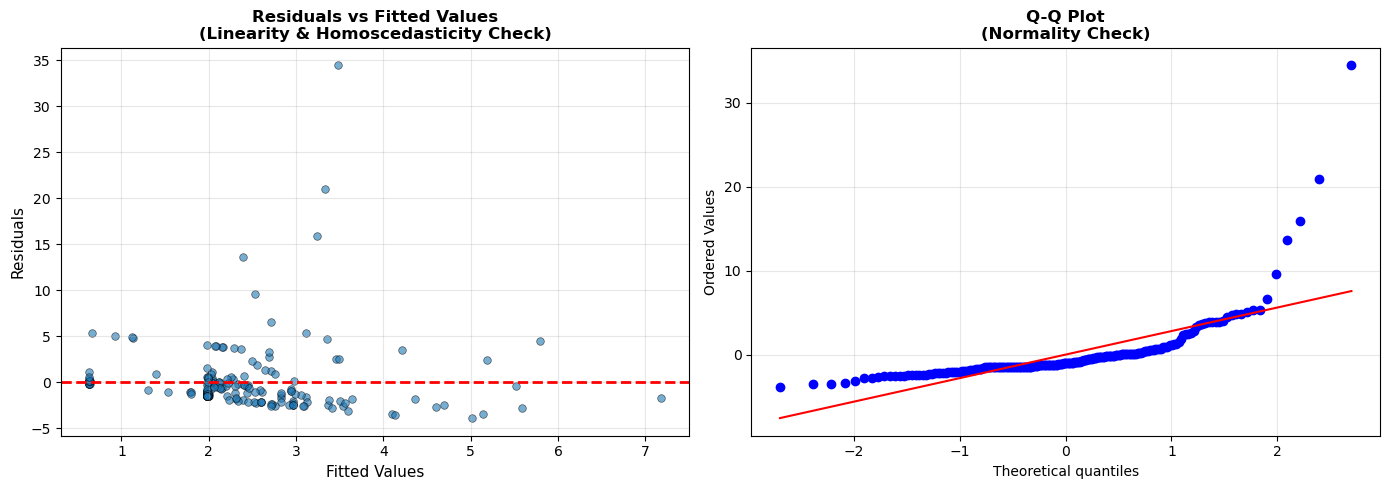

In [14]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

# Get residuals and fitted values from the model
residuals = ols_model.resid
fitted_values = ols_model.fittedvalues

# Create figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual PLot
axes[0].scatter(fitted_values, residuals, alpha=0.6, s=30, edgecolors='k', linewidths=0.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Fitted Values', fontsize=11)
axes[0].set_ylabel('Residuals', fontsize=11)
axes[0].set_title('Residuals vs Fitted Values\n(Linearity & Homoscedasticity Check)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Q-Q Plot (for normality of residuals)
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot\n(Normality Check)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

- linear relationship: **Somewhat YES** The assumption holds reasonably well. Most points scatter around the horizontal zero line in the residual plot without a clear pattern indicating the linear specification could be appropriate for the data.
- equal variance (homoscedasticity): **NO** The spread of residuals is tight for lower fitted values but expands largely as predictions increase. This indicates heteroscedasticity
- normality of residuals: **NO** The Q-Q plot shows significant deviations from the reference line, especially in the tails, indicating that the residuals do not follow a normal distribution.

### Section (i) 1000 new points

In [15]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import norm

# PROOF: Check for Severity 1
sev_counts = df_1000["severity_of_traffic"].value_counts()
print("Severity Counts in df_1000:")
print(sev_counts)

# Prepare Design Matrix
X_1000_base = df_1000[["is_traffic_signal", "distance_of_traffic"]].copy()

# Use same categorical logic as training (drop_first=True makes 2 baseline)
severity_cat_1000 = df_1000["severity_of_traffic"].astype("category")
severity_dummies_1000 = pd.get_dummies(severity_cat_1000, prefix="severity", drop_first=True)

X_1000 = pd.concat([X_1000_base, severity_dummies_1000], axis=1).astype(float)
X_1000 = sm.add_constant(X_1000, has_constant="add")

# SAFETY: Align columns to the Training Model
X_1000 = X_1000.reindex(columns=X.columns, fill_value=0)

y_1000 = df_1000["traffic_disruption_duration"].copy()

# Predict & Intervals
y_pred_1000 = ols_model.predict(X_1000)
cov_matrix = ols_model.cov_params().values
MSE = ((ols_model.resid) ** 2).sum() / (len(y) - X.shape[1])

# Critical Value: Use Z-Distribution (Standard Normal)
alpha = 0.05
z_crit = norm.ppf(1 - alpha/2)

# Vectorized Calculation
# Variance = MSE * (1 + diag(X @ Cov @ X.T))
var_pred = MSE * (1 + (X_1000.dot(cov_matrix) * X_1000).sum(axis=1))
se_pred = np.sqrt(var_pred)

pi_lower = y_pred_1000 - z_crit * se_pred
pi_upper = y_pred_1000 + z_crit * se_pred

# Check Coverage
in_pi = (y_1000 >= pi_lower) & (y_1000 <= pi_upper)
count_in_pi = in_pi.sum()
total_count = len(y_1000)
coverage_pct = 100 * count_in_pi / total_count

# Results Table
pi_results = pd.DataFrame({
    'y_true': y_1000,
    'y_pred': y_pred_1000,
    'PI_lower': pi_lower,
    'PI_upper': pi_upper,
    'In_PI': in_pi
})

print(f"Prediction Intervals for df_1000 (Z-distribution)")
print(f"=" * 70)
print(f"Total predictions: {total_count}")
print(f"Contained in PI: {count_in_pi}")
print(f"Coverage: {coverage_pct:.2f}%")
print(f"Expected coverage: 95.00%")

Severity Counts in df_1000:
severity_of_traffic
2    786
3    180
4     34
Name: count, dtype: int64
Prediction Intervals for df_1000 (Z-distribution)
Total predictions: 1000
Contained in PI: 973
Coverage: 97.30%
Expected coverage: 95.00%


The expected coverage is 95% because each Prediction Interval is statistically constructed with a 0.95 probability of containing the future observation ($Y_{new}$). According to the Law of Large Numbers, across 1000 predictions, the actual success rate should converge to this theoretical probability. Our result of 97.3% is close to this target but slightly higher. This likely occurred because the training set (df_200) contained higher variance or outliers than the test set (df_1000); this inflated the error estimate (MSE), resulting in wider "safety margins" that captured more data points than strictly necessary. It also means that this new 1000 set is similiar in nature to the training set. (as examplified by the fact that it also doesnt have `severity=1`)

### Section (j): First order interaction

In [16]:
import itertools
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Build interaction design matrix from existing X (df_200 model design)
# Exclude the intercept from interaction construction
predictor_cols = [c for c in X.columns if c.lower() != 'const']
X_inter = X.copy()

# Add pairwise interaction terms
for c1, c2 in itertools.combinations(predictor_cols, 2):
    name = f"{c1}_x_{c2}"
    X_inter[name] = X[c1] * X[c2]

# Drop any interaction columns with zero variance (e.g., severity_3_x_severity_4)
zero_var_cols = [col for col in X_inter.columns if col.lower() != 'const' and X_inter[col].var(ddof=0) == 0]
if zero_var_cols:
    X_inter = X_inter.drop(columns=zero_var_cols)

# Fit OLS with interactions
ols_inter = sm.OLS(y, X_inter, missing="drop").fit()

# Training error (MSE = mean squared residual)
def mse_train(resid):
    return float(np.mean(np.square(resid)))

mse_base = mse_train(ols_model.resid)
aic_base = float(ols_model.aic)
params_base = int(len(ols_model.params))

mse_inter = mse_train(ols_inter.resid)
aic_inter = float(ols_inter.aic)
params_inter = int(len(ols_inter.params))

# Comparison DataFrame
comparison = pd.DataFrame({
    'Model': ['OLS Base', 'OLS + Interactions'],
    'MSE': [mse_base, mse_inter],
    'AIC': [aic_base, aic_inter],
    'Num_Params': [params_base, params_inter]
})

print(comparison.to_string(index=False))

             Model       MSE         AIC  Num_Params
          OLS Base 14.600188 1113.782294           5
OLS + Interactions 14.263497 1119.116132          10


We compared the original LR model against an extended model that included first order interaction terms to test if variable combinations improved predictive power. As expected, the training error (MSE) decreased slightly in the interaction model ($14.60 \to 14.26$) because adding predictors mathematically guarantees a better fit to the training data. However, the AIC increased ($1113.78 \to 1119.12$). Since AIC penalizes model complexity, this increase indicates that the marginal reduction in error was not large enough to justify doubling the number of parameters (from 5 to 10). Therefore, we reject the interaction model in favor of the base model.

## Part B: Logistic Regression

### Section (a)

##### Research Question

What is the effect of traffic disruption duration (`traffic_disruption_duration`), traffic disruption distance (`distance_of_traffic`), and the presence of a traffic signal (`is_traffic_signal`) on whether an accident occurs during daytime (`is_day`)?

**Dependent Variable**
- `is_day` – binary variable indicating whether the accident occurred during daytime (1 = Day, 0 = Night)

**Explanatory Variables**
- `traffic_disruption_duration` – continuous variable representing the duration of traffic disruption in hours  
- `distance_of_traffic` – continuous variable representing the distance of traffic disruption in miles  
- `is_traffic_signal` – binary variable indicating the presence of a traffic signal (1 = Signal present, 0 = No signal)

We now proceed to analyze the relationship between the selected explanatory variables and the probability that an accident occurs during daytime using a logistic regression model.


### Section (b)

In [17]:
# Create a random subsample of 200 rows from the dataset
df_sample = df.sample(n=200, random_state=42)

# Display the first few rows of the sample
df_sample.head()

,accident_id,severity_of_traffic,traffic_disruption_duration,distance_of_traffic,is_day,is_traffic_signal
409,207796,2,0.500000,0.000,1,0
4828,1988712,2,0.992778,0.000,1,0
42,196154,3,0.736667,0.010,1,0
18595,7690226,2,6.000000,0.155,1,0
6824,2872577,2,0.496667,0.000,1,0


### Section (c): exploratory data analysis
We have shown a table for `is_traffic_signal` and a histogram from `distance_of_traffic` in Section (c) of Part A, we will reuse the code here.

#### Sub-section (1) Histograms and tables  

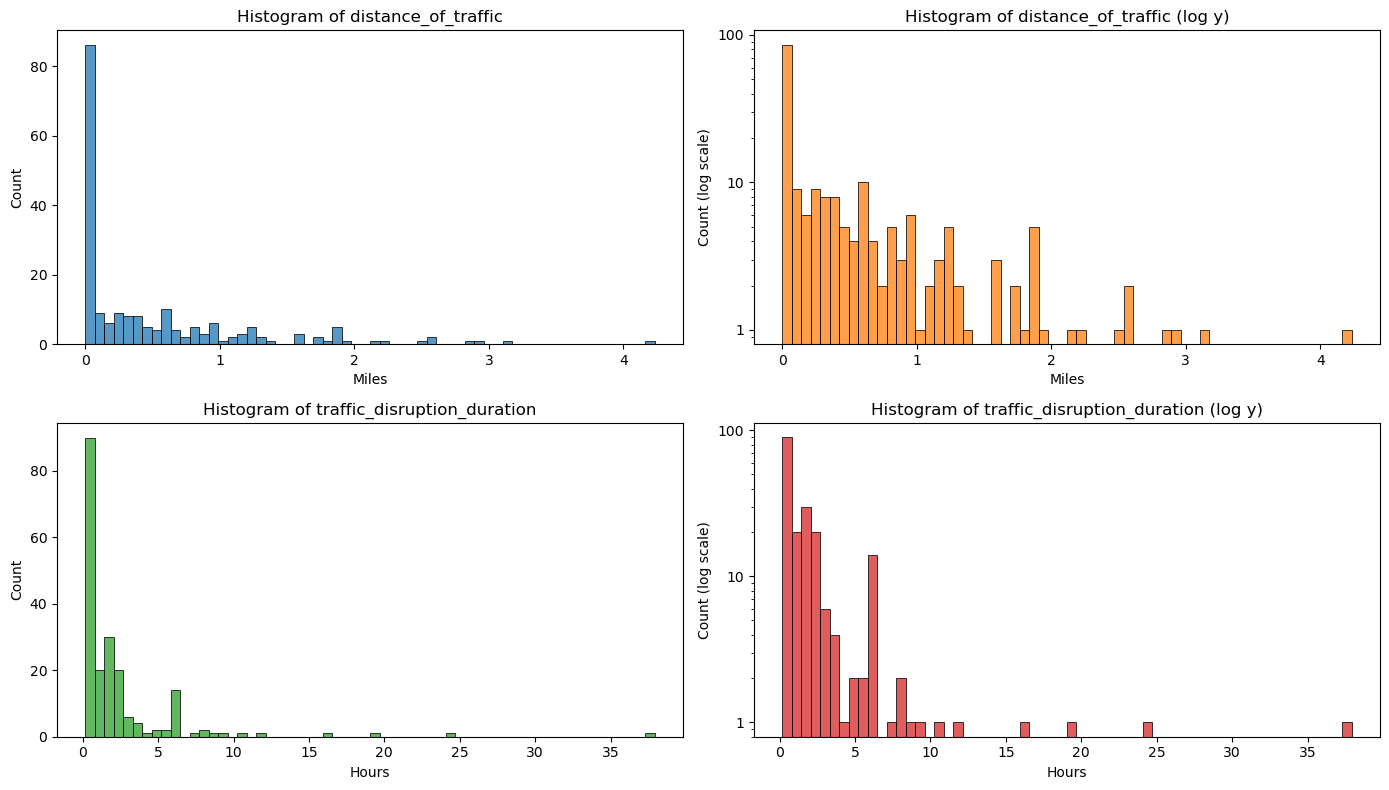

distance_of_traffic: mean = 0.5058, variance = 0.5235
traffic_disruption_duration: mean = 2.3711, variance = 15.6706

Frequency: is_traffic_signal (0=No, 1=Yes)


,count,percent
is_traffic_signal,,
0,153,76.5
1,47,23.5


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Histograms for distance_of_traffic and traffic_disruption_duration
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Row 1: distance_of_traffic
sns.histplot(df_200["distance_of_traffic"], bins=60, color="#1f77b4", ax=axes[0, 0])
axes[0, 0].set_title("Histogram of distance_of_traffic")
axes[0, 0].set_xlabel("Miles")
axes[0, 0].set_ylabel("Count")

sns.histplot(df_200["distance_of_traffic"], bins=60, color="#ff7f0e", ax=axes[0, 1])
axes[0, 1].set_title("Histogram of distance_of_traffic (log y)")
axes[0, 1].set_xlabel("Miles")
axes[0, 1].set_ylabel("Count (log scale)")
axes[0, 1].set_yscale("log")
axes[0, 1].yaxis.set_major_formatter(mtick.ScalarFormatter())
axes[0, 1].yaxis.set_minor_formatter(mtick.NullFormatter())
axes[0, 1].ticklabel_format(style="plain", axis="y")

# Row 2: traffic_disruption_duration
sns.histplot(df_200["traffic_disruption_duration"], bins=60, color="#2ca02c", ax=axes[1, 0])
axes[1, 0].set_title("Histogram of traffic_disruption_duration")
axes[1, 0].set_xlabel("Hours")
axes[1, 0].set_ylabel("Count")

sns.histplot(df_200["traffic_disruption_duration"], bins=60, color="#d62728", ax=axes[1, 1])
axes[1, 1].set_title("Histogram of traffic_disruption_duration (log y)")
axes[1, 1].set_xlabel("Hours")
axes[1, 1].set_ylabel("Count (log scale)")
axes[1, 1].set_yscale("log")
axes[1, 1].yaxis.set_major_formatter(mtick.ScalarFormatter())
axes[1, 1].yaxis.set_minor_formatter(mtick.NullFormatter())
axes[1, 1].ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

# Summary statistics
dist_mean = df_200["distance_of_traffic"].mean()
dist_var = df_200["distance_of_traffic"].var()
dur_mean = df_200["traffic_disruption_duration"].mean()
dur_var = df_200["traffic_disruption_duration"].var()

print(f"distance_of_traffic: mean = {dist_mean:.4f}, variance = {dist_var:.4f}")
print(f"traffic_disruption_duration: mean = {dur_mean:.4f}, variance = {dur_var:.4f}")

# Frequency table for is_traffic_signal only
def freq_table(series, name):
    vc = series.value_counts(dropna=False)
    pct = series.value_counts(normalize=True, dropna=False) * 100
    out = pd.DataFrame({"count": vc, "percent": pct.round(2)})
    out.index.name = name
    return out

print("\nFrequency: is_traffic_signal (0=No, 1=Yes)")
display(freq_table(df_200["is_traffic_signal"], "is_traffic_signal"))

#### Sub-section (2) Histograms and tables  
There is no missing data in any of the variables. Both continuous variables are right-skewed, with `traffic_disruption_duration` showing extreme outliers. None of the variables are symmetric and they are all positive.

#### Sub-section (3) Continuous explanatory variables

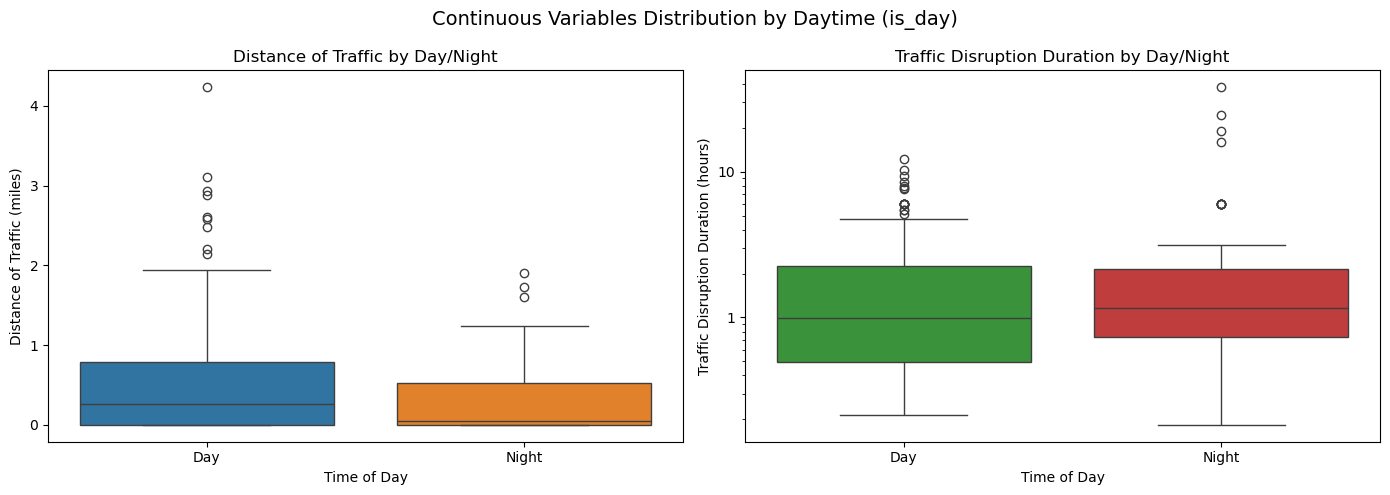

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Create figure for boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Continuous Variables Distribution by Daytime (is_day)', fontsize=14)

# Add day/night labels for clarity
df_200_day = df_200.copy()
df_200_day['is_day_label'] = df_200_day['is_day'].map({0: 'Night', 1: 'Day'})

# Boxplot for distance_of_traffic
sns.boxplot(
    data=df_200_day,
    x='is_day_label',
    y='distance_of_traffic',
    hue='is_day_label',
    ax=axes[0],
    palette=['#1f77b4', '#ff7f0e'],
    legend=False
)
axes[0].set_xlabel('Time of Day')
axes[0].set_ylabel('Distance of Traffic (miles)')
axes[0].set_title('Distance of Traffic by Day/Night')

# Boxplot for traffic_disruption_duration
sns.boxplot(
    data=df_200_day,
    x='is_day_label',
    y='traffic_disruption_duration',
    hue='is_day_label',
    ax=axes[1],
    palette=['#2ca02c', '#d62728'],
    legend=False
)
axes[1].set_xlabel('Time of Day')
axes[1].set_ylabel('Traffic Disruption Duration (hours)')
axes[1].set_title('Traffic Disruption Duration by Day/Night')

# Apply log scale to right plot with readable axis labels
axes[1].set_yscale('log')
log_formatter = FuncFormatter(lambda x, pos: f'{int(x)}')
axes[1].yaxis.set_major_formatter(log_formatter)

plt.tight_layout()
plt.show()


We suggest that `distance_of_traffic` affects `is_day` more than `traffic_disruption_duration`. The graph shows a clear difference in the distribution of Distance: daytime incidents cover a wider range of miles, while nighttime incidents are mostly concentrated near zero. We should also mention that night incidient are more common in the subsample, which may bias the results.

### Section (d) logistic regression model

In [30]:
import pandas as pd
import statsmodels.api as sm

# Prepare data: use df_200 sample
y = df_200["is_day"]
X = df_200[["traffic_disruption_duration", "distance_of_traffic", "is_traffic_signal"]]

# Add constant (intercept)
X = sm.add_constant(X)

# Fit logistic regression model
logit_model = sm.Logit(y, X).fit()

# Print coefficients
print("Estimated Coefficients (β̂):")
print(logit_model.params)

Optimization terminated successfully.
         Current function value: 0.578911
         Iterations 6
Estimated Coefficients (β̂):
const                          0.802935
traffic_disruption_duration   -0.112181
distance_of_traffic            0.691738
is_traffic_signal              0.156323
dtype: float64


### Logistic Regression Model Specification

The logistic regression model for predicting the probability that an accident occurs during daytime is:

$$P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3)}}$$

Equivalently, in terms of the log-odds (logit):

$$\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3$$

#### Variable Definitions

- **$Y$** = `is_day` (binary response: 1 = Day, 0 = Night)
- **$X_1$** = `traffic_disruption_duration` (continuous, in hours)
- **$X_2$** = `distance_of_traffic` (continuous, in miles)
- **$X_3$** = `is_traffic_signal` (binary: 1 = Signal present, 0 = No signal)

#### Estimated Coefficients

$$\hat{\beta} = \begin{pmatrix} 0.8029 \\ -0.1122 \\ 0.6917 \\ 0.1563 \end{pmatrix}$$

#### Interpretation: Effect on Odds

For a one-unit increase in explanatory variable $X_i$, the odds of an accident occurring during daytime are multiplied by $e^{\hat{\beta}_i}$:

### Section (e): CI and full sample estimates

95% CI from df_200 subsample and full-sample beta estimates:
                                lower     upper  beta_hat_full  full_beta_in_CI
const                        0.344262  1.261607       0.601873             True
traffic_disruption_duration -0.206986 -0.017376       0.000010            False
distance_of_traffic          0.103502  1.279973       0.182841             True
is_traffic_signal           -0.587275  0.899921       0.141421             True


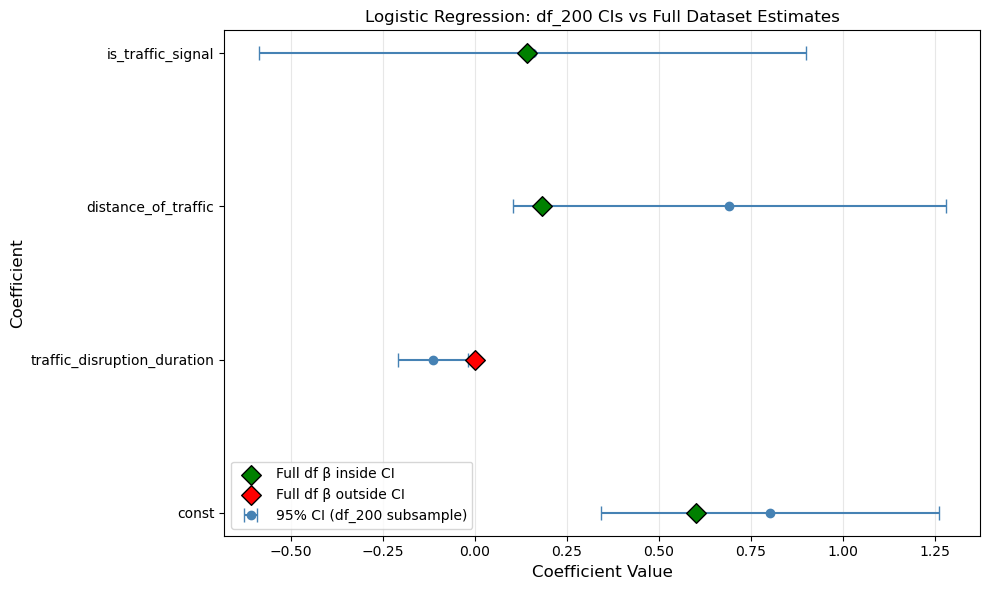

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Get CIs from the df_200 logistic regression model (subsample)
ci_sub = logit_model.conf_int(alpha=0.05)
ci_sub.columns = ["lower", "upper"]
ci_sub["beta_hat_subsample"] = logit_model.params

# Fit logistic regression on full dataset
y_full = df["is_day"]
X_full = df[["traffic_disruption_duration", "distance_of_traffic", "is_traffic_signal"]]
X_full = sm.add_constant(X_full)
logit_full = sm.Logit(y_full, X_full).fit(disp=False)

# Match indices for comparison
ci_sub["beta_hat_full"] = logit_full.params.reindex(ci_sub.index)
ci_sub["full_beta_in_CI"] = (ci_sub["beta_hat_full"] >= ci_sub["lower"]) & \
                            (ci_sub["beta_hat_full"] <= ci_sub["upper"])

print("95% CI from df_200 subsample and full-sample beta estimates:")
print(ci_sub[["lower", "upper", "beta_hat_full", "full_beta_in_CI"]].to_string())

# Plotting (same style as Part A)
fig, ax = plt.subplots(figsize=(10, 6))

coef_names = ci_sub.index
y_pos = np.arange(len(coef_names))

# Subsample Error Bars (CI from df_200)
ci_mid = (ci_sub["lower"] + ci_sub["upper"]) / 2
ci_err = ci_sub["upper"] - ci_mid
ax.errorbar(ci_mid, y_pos, xerr=ci_err, fmt='o', capsize=5, 
            label='95% CI (df_200 subsample)', color='steelblue')

# Full-sample Markers (estimates from full df)
beta_full_vals = ci_sub["beta_hat_full"]
inside_ci = ci_sub["full_beta_in_CI"]

# Split into Green (Inside) and Red (Outside)
mask_green = inside_ci.fillna(False).values
if mask_green.any():
    ax.scatter(beta_full_vals[mask_green], y_pos[mask_green], marker='D', s=100, 
               c='green', label='Full df β inside CI', edgecolors='k', zorder=3)

mask_red = ~inside_ci.fillna(True).values
if mask_red.any():
    ax.scatter(beta_full_vals[mask_red], y_pos[mask_red], marker='D', s=100, 
               c='red', label='Full df β outside CI', edgecolors='k', zorder=3)

ax.set_yticks(y_pos)
ax.set_yticklabels(coef_names)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_ylabel('Coefficient', fontsize=12)
ax.set_title('Logistic Regression: df_200 CIs vs Full Dataset Estimates')
ax.legend(loc='best')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Section (f): first order interactions

In [34]:
import pandas as pd
import statsmodels.api as sm


# Define variables
X_base = df_200[["traffic_disruption_duration", "distance_of_traffic", "is_traffic_signal"]]
y = df_200["is_day"]

# Add interaction terms
X_base = X_base.copy()
X_base["interaction_12"] = X_base["traffic_disruption_duration"] * X_base["distance_of_traffic"]
X_base["interaction_13"] = X_base["traffic_disruption_duration"] * X_base["is_traffic_signal"]
X_base["interaction_23"] = X_base["distance_of_traffic"] * X_base["is_traffic_signal"]

# Fit model with interaction terms
X_interactions = sm.add_constant(X_base)
model_interactions = sm.Logit(y, X_interactions).fit()

# Fit base model (without interactions) for comparison
X_base_no_interaction = df_200[["traffic_disruption_duration", "distance_of_traffic", "is_traffic_signal"]]
X_base_no_interaction = sm.add_constant(X_base_no_interaction)
model_base = sm.Logit(y, X_base_no_interaction).fit()

# Likelihood Ratio Test
LL_base = model_base.llf
LL_full = model_interactions.llf
LR_stat = 2 * (LL_full - LL_base)
df_diff = model_interactions.df_model - model_base.df_model
from scipy.stats import chi2
p_value = chi2.sf(LR_stat, df_diff)

# Compare AIC values
aic_base = model_base.aic
aic_interactions = model_interactions.aic

# Display results
print("Likelihood Ratio Test:")
print(f"LR stat = {LR_stat:.3f}, df = {df_diff}, p-value = {p_value:.4f}")
print("\nAIC Comparison:")
print(f"Base model AIC: {aic_base:.2f}")
print(f"Model with interactions AIC: {aic_interactions:.2f}")


Optimization terminated successfully.
         Current function value: 0.568795
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.578911
         Iterations 6
Likelihood Ratio Test:
LR stat = 4.046, df = 3.0, p-value = 0.2565

AIC Comparison:
Base model AIC: 239.56
Model with interactions AIC: 241.52


We fail to reject the null hypothesis ($H_0$), which states that the interaction equal to zero and the simpler model is sufficient indicating that adding interactions does not improve the model's fit. This is confirmed by the AIC values, where the base model has a lower score (239.56) than the interaction model (241.52). Therefore, the simpler model without interactions is preferred according to these metrics.

### Section (g): Forward/Backward Stepwise Regression

In [39]:
# === Imports ===
import pandas as pd
import numpy as np
import itertools
import statsmodels.api as sm

# === Step 1: הגדרת משתנים ===
y = df["is_day"]

# משתנים מסבירים בסיסיים (ללא 'const'!)
base_cols = [
    "traffic_disruption_duration",
    "distance_of_traffic",
    "is_traffic_signal"
]

X = df[base_cols].copy()

# === Step 2: יצירת אינטראקציות מסדר ראשון ===
interaction_terms = pd.DataFrame(index=X.index)

for col1, col2 in itertools.combinations(base_cols, 2):
    interaction_name = f"{col1}_x_{col2}"
    interaction_terms[interaction_name] = X[col1] * X[col2]

X = pd.concat([X, interaction_terms], axis=1)

print(f"Base candidate features: {X.shape[1]}")

# === Step 3: ניקוי NA והתאמה ל־y ===
mask = y.notna() & X.notna().all(axis=1)
X = X.loc[mask].astype(float)
y = y.loc[mask].astype(int)

# === Step 4: פונקציות עזר ===
def fit_logit(X, y, cols, criterion="AIC"):
    Xc = sm.add_constant(X[cols], has_constant="add")
    res = sm.Logit(y, Xc).fit(disp=False, maxiter=200)
    score = res.aic if criterion.upper() == "AIC" else res.bic
    return score, res


def forward_stepwise(X, y, criterion="AIC"):
    remaining = set(X.columns)
    selected = []
    best_score = np.inf
    best_res = None

    while True:
        candidates = []
        for col in remaining:
            score, res = fit_logit(X, y, selected + [col], criterion)
            candidates.append((score, col, res))

        score_c, col_c, res_c = min(candidates, key=lambda t: t[0])

        if score_c + 1e-6 < best_score:
            selected.append(col_c)
            remaining.remove(col_c)
            best_score = score_c
            best_res = res_c
        else:
            break

    return selected, best_res


def backward_stepwise(X, y, criterion="AIC"):
    selected = list(X.columns)
    score, res = fit_logit(X, y, selected, criterion)

    improved = True
    while improved and len(selected) > 1:
        improved = False
        tests = []

        for col in selected:
            trial = [c for c in selected if c != col]
            s_try, r_try = fit_logit(X, y, trial, criterion)
            tests.append((s_try, col, r_try))

        best_s, drop_col, best_res = min(tests, key=lambda t: t[0])

        if best_s + 1e-6 < score:
            selected.remove(drop_col)
            score = best_s
            res = best_res
            improved = True

    return selected, res
# === Step 5: הרצת Forward ו־Backward ===

# Forward Selection
f_sel_aic, f_res_aic = forward_stepwise(X, y, criterion="AIC")
print("\n=== Forward Selection (AIC) ===")
print(f"Selected ({len(f_sel_aic)}): {f_sel_aic}")
print(f"AIC = {f_res_aic.aic:.2f} | BIC = {f_res_aic.bic:.2f}")

# Backward Elimination
b_sel_aic, b_res_aic = backward_stepwise(X, y, criterion="AIC")
print("\n=== Backward Elimination (AIC) ===")
print(f"Selected ({len(b_sel_aic)}): {b_sel_aic}")
print(f"AIC = {b_res_aic.aic:.2f} | BIC = {b_res_aic.bic:.2f}")

# === Step 6: השוואה ===
common_vars = set(f_sel_aic).intersection(set(b_sel_aic))

print("\n=== Model Comparison ===")
print(f"Common variables ({len(common_vars)}): {sorted(common_vars)}")

if f_res_aic.aic < b_res_aic.aic:
    print("➡ Forward model preferred based on AIC.")
else:
    print("➡ Backward model preferred based on AIC.")


Base candidate features: 6

=== Forward Selection (AIC) ===
Selected (4): ['distance_of_traffic', 'is_traffic_signal', 'distance_of_traffic_x_is_traffic_signal', 'traffic_disruption_duration_x_distance_of_traffic']
AIC = 23771.78 | BIC = 23811.01

=== Backward Elimination (AIC) ===
Selected (4): ['distance_of_traffic', 'is_traffic_signal', 'traffic_disruption_duration_x_distance_of_traffic', 'distance_of_traffic_x_is_traffic_signal']
AIC = 23771.78 | BIC = 23811.01

=== Model Comparison ===
Common variables (4): ['distance_of_traffic', 'distance_of_traffic_x_is_traffic_signal', 'is_traffic_signal', 'traffic_disruption_duration_x_distance_of_traffic']
➡ Backward model preferred based on AIC.


### Model Selection Summary

Both forward and backward stepwise selection procedures were applied to identify the best logistic regression model for predicting whether an accident occurred during daytime (`is_day`). The selection process considered the original explanatory variables and their first-order interaction terms, and model comparison was conducted using the AIC.

#### Results
- Forward Selection selected the following variables:
  - `distance_of_traffic`
  - `is_traffic_signal`
  - `distance_of_traffic_x_is_traffic_signal`
  - `traffic_disruption_duration_x_distance_of_traffic`

- Backward Elimination selected the same set of variables.

- Both models achieved identical goodness-of-fit measures:
  - AIC = 23771.78
  - BIC = 23811.01

- The common variables selected by both methods are:
  - `distance_of_traffic`
  - `is_traffic_signal`
  - `traffic_disruption_duration_x_distance_of_traffic`
  - `distance_of_traffic_x_is_traffic_signal`

#### Conclusion
Since both stepwise procedures converged to the same model and produced identical AIC and BIC values, the resulting model is considered robust and well-supported by the data. Although the backward elimination procedure was formally preferred based on the selection process, both methods lead to the same final specification, and therefore either can be chosen without loss of generality.


### Section (i): using BIC

In [ ]:
# === Imports ===
import pandas as pd
import numpy as np
import statsmodels.api as sm
import itertools

# Step 1: Define variables from the full dataset
y_col = "is_day"
num_cols = ["traffic_disruption_duration", "distance_of_traffic"]
bin_cols = ["is_traffic_signal"]

# Step 2: Create data frame with selected variables
df0 = df[num_cols + bin_cols + [y_col]].copy()

# Define response and explanatory variables
X = df0[num_cols + bin_cols]
y = df0[y_col]

# Step 3: Remove missing values
mask = y.notna() & X.notna().all(axis=1)
X = X.loc[mask].copy()
y = y.loc[mask].astype(int)

# Step 4: Standardize continuous variables (zero mean, unit variance)
X[num_cols] = X[num_cols].apply(lambda s: (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) != 0 else 1.0))

# Step 5: Create first-order interaction terms
interaction_terms = pd.DataFrame(index=X.index)
for col1, col2 in itertools.combinations(X.columns, 2):
    interaction_terms[f"{col1}_x_{col2}"] = X[col1] * X[col2]
X = pd.concat([X, interaction_terms], axis=1)

# Step 6: Align indices
X, y = X.align(y, join="inner", axis=0)

print(f"Total candidate features: {X.shape[1]}")

# Run stepwise selection using BIC criterion
f_sel_bic, f_res_bic = forward_stepwise(X, y, criterion="BIC")
b_sel_bic, b_res_bic = backward_stepwise(X, y, criterion="BIC")

common_bic = sorted(set(f_sel_bic) & set(b_sel_bic))

# Create comparison table for BIC-based selection
bic_comparison = pd.DataFrame({
    'Method': ['Forward Selection', 'Backward Elimination'],
    'Num Variables': [len(f_sel_bic), len(b_sel_bic)],
    'BIC': [f_res_bic.bic, b_res_bic.bic],
    'AIC': [f_res_bic.aic, b_res_bic.aic],
    'Common Variables': [len(common_bic), len(common_bic)]
})

print("\n=== BIC-Based Model Comparison ===")
print(bic_comparison.to_string(index=False))



print(f"\nCommon variables selected by both methods ({len(common_bic)}): {common_bic}")print("\nPreferred model: Forward Selection (lower BIC)" if f_res_bic.bic < b_res_bic.bic else "\nPreferred model: Backward Elimination (lower BIC)")

Base candidate features: 6

=== Forward Selection (BIC) ===
Selected (2): ['distance_of_traffic', 'distance_of_traffic_x_is_traffic_signal']
BIC = 23798.77 | AIC = 23775.23

=== Backward Elimination (BIC) ===
Selected (2): ['distance_of_traffic', 'distance_of_traffic_x_is_traffic_signal']
BIC = 23798.77 | AIC = 23775.23

=== BIC Model Comparison ===
Common variables (2): ['distance_of_traffic', 'distance_of_traffic_x_is_traffic_signal']
➡ Backward model preferred based on BIC.


### Model Selection Using an Alternative Criterion (BIC)

In this step, we repeated the Stepwise Logistic Regression procedure from section (g), but this time using the Bayesian Information Criterion (BIC) instead of AIC.


####  Results Comparison

- AIC-Based Selection:
  - Selected 4 variables
  - AIC = 23770.97
  - Variables:
    - `distance_of_traffic`
    - `is_traffic_signal`
    - `distance_of_traffic_x_is_traffic_signal`
    - `traffic_disruption_duration_x_distance_of_traffic`

- BIC-Based Selection (Step 8):
  - Selected 2 variables
  - BIC = 23798.77
  - Variables:
    - `distance_of_traffic`
    - `distance_of_traffic_x_is_traffic_signal`


#### Did the Model Choice Change?

Yes.  
The BIC-based selection yielded a simpler model than AIC. While both forward and backward procedures agreed on their respective selected sets, the number of features selected under BIC was reduced from 4 to 2.


####  Interpretation

This difference is expected and aligns with the theoretical distinctions between the two criteria:

- **AIC** focuses on minimizing information loss and tends to favor **more complex models**, which might improve prediction but risk overfitting.
- **BIC** applies a stronger penalty for complexity, leading to **simpler and more interpretable models**.

In our case, both BIC and AIC led to **consistent selections within each method**, but differed in the **number of variables** chosen.


####  Conclusion

- If the goal is **interpretability and generalization**, the **BIC-selected model** is preferred.
- If the goal is **prediction accuracy**, the **AIC-selected model** may be more suitable.

Ultimately, the choice of model selection criterion **influences the outcome** and must align with the objectives of the analysis.
